1. Признаки weight, height, age, gender будут самые важные по feature importance в дереве
2. Если взять эти 4 важных признака, логистическая регрессия будет работать не хуже(по метрике r2 например).
3. Можно создать новый признак "индекс массы тела", и например еще оставить age. На этих двух признаках модель логистической регрессии должна показать адекватный результат.
4. standartScaler не даст прироста при использовании двух признаков: bmi, age.
5. При использовании двух признаков bmi, age нет смысла в деревьях, достаточно логистической регресии(метрики не будут хуже).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')

In [4]:
df.shape

(2111, 17)

In [5]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

Все классы распределены одинаково примерно

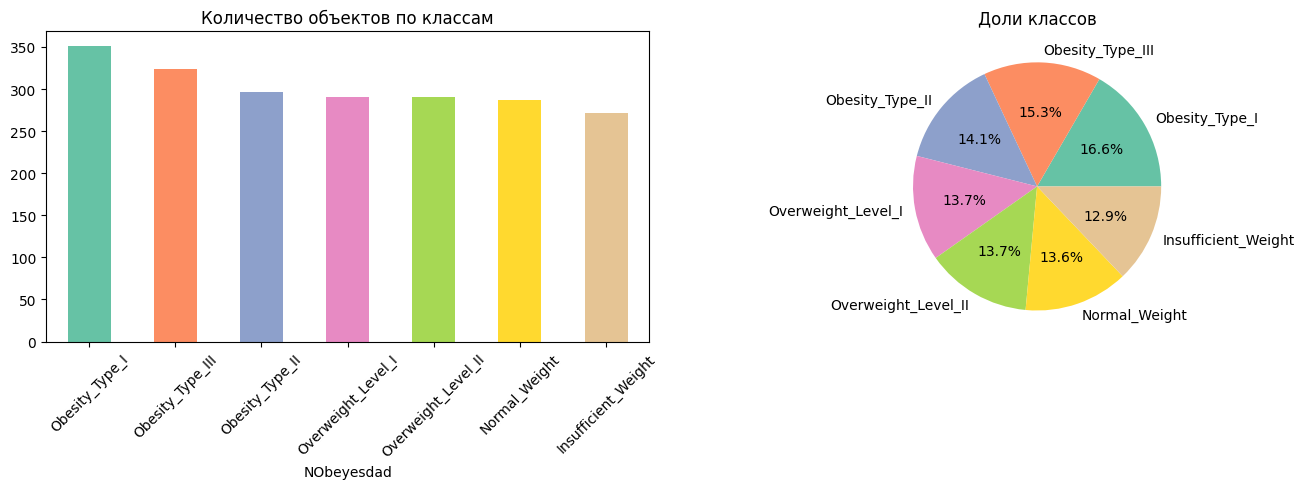

In [8]:
target_col = 'NObeyesdad'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

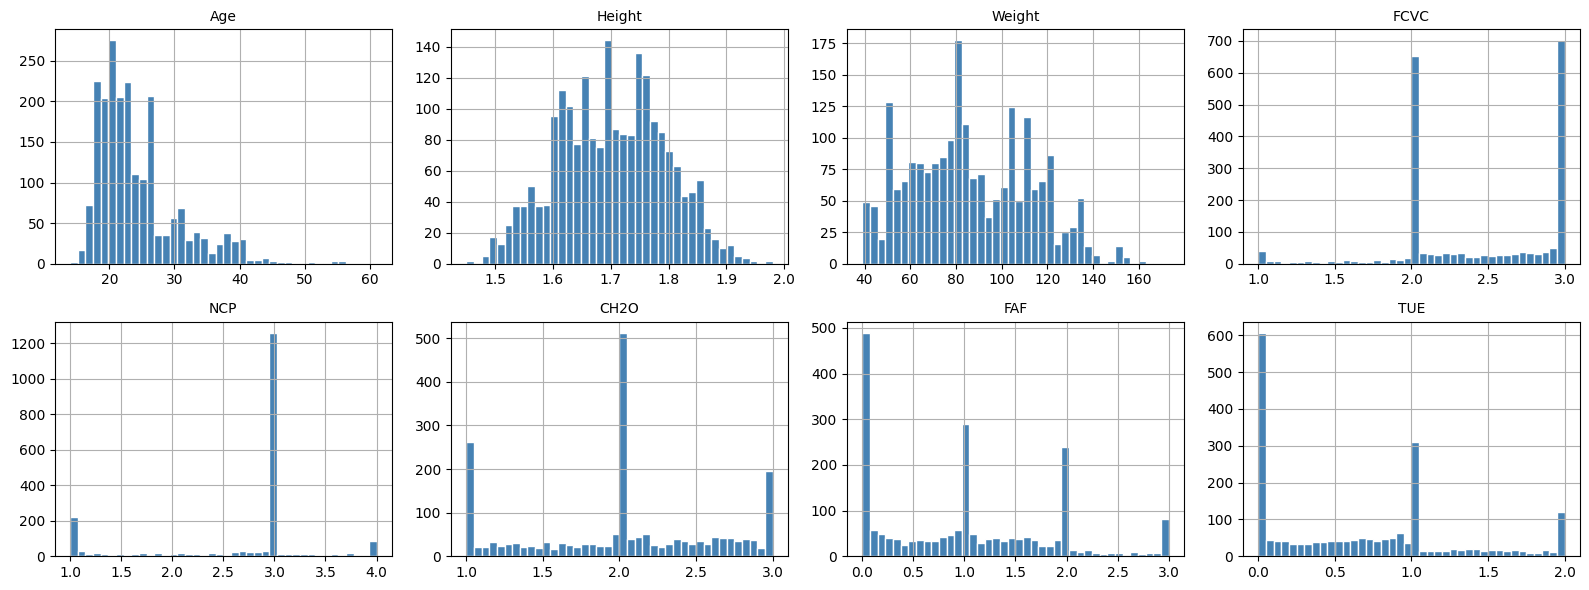

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

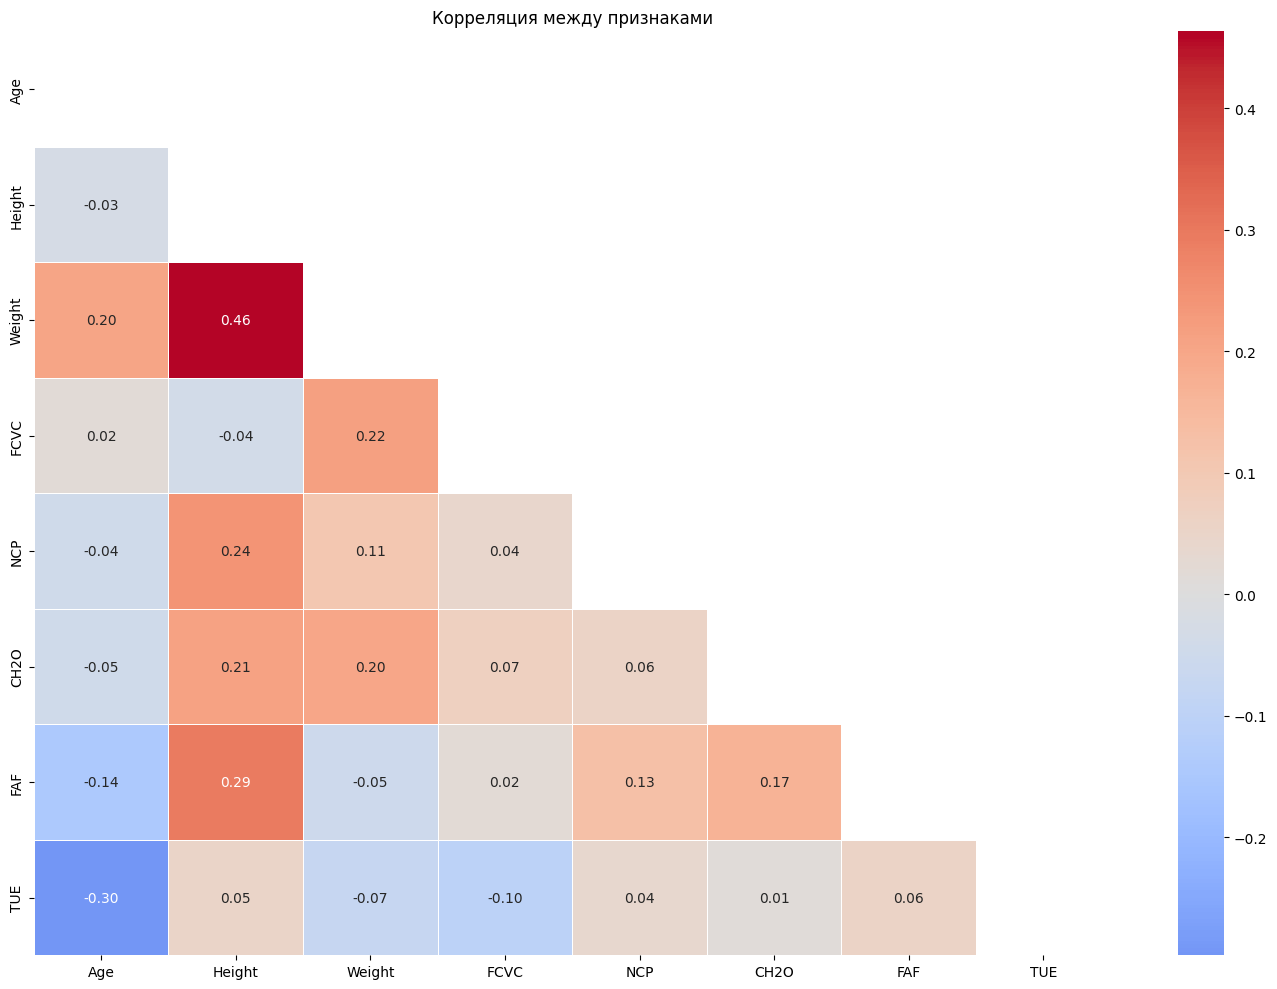

In [10]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Величины по типу: fcvc, ncp, fav пробегают все значения у всех классов. Вероятно можно исключить

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


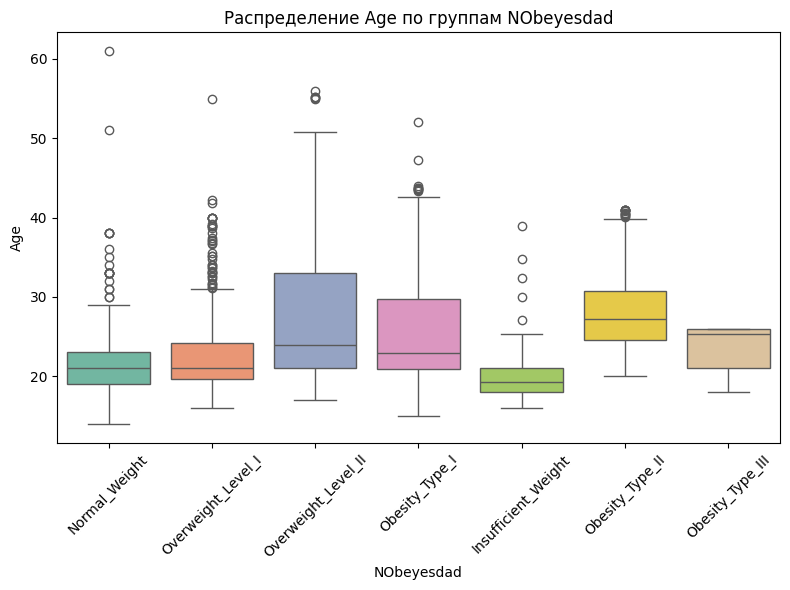

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


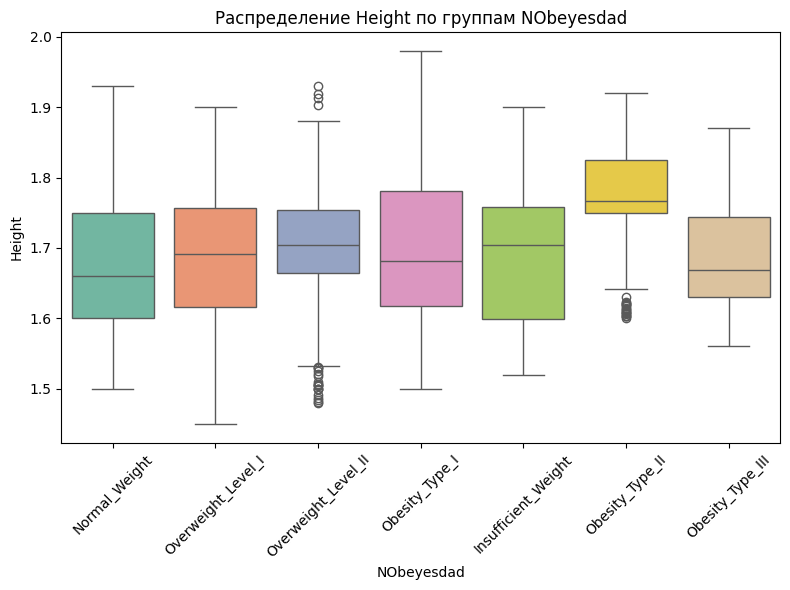

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


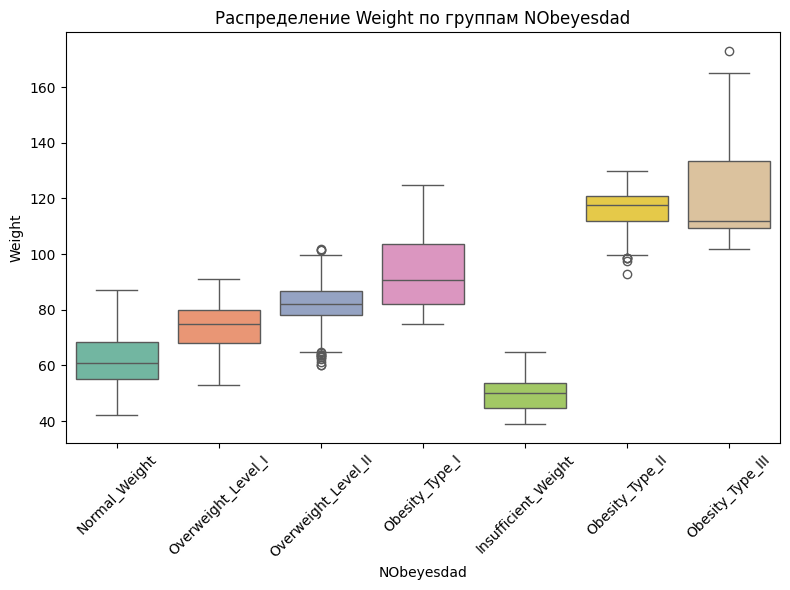

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


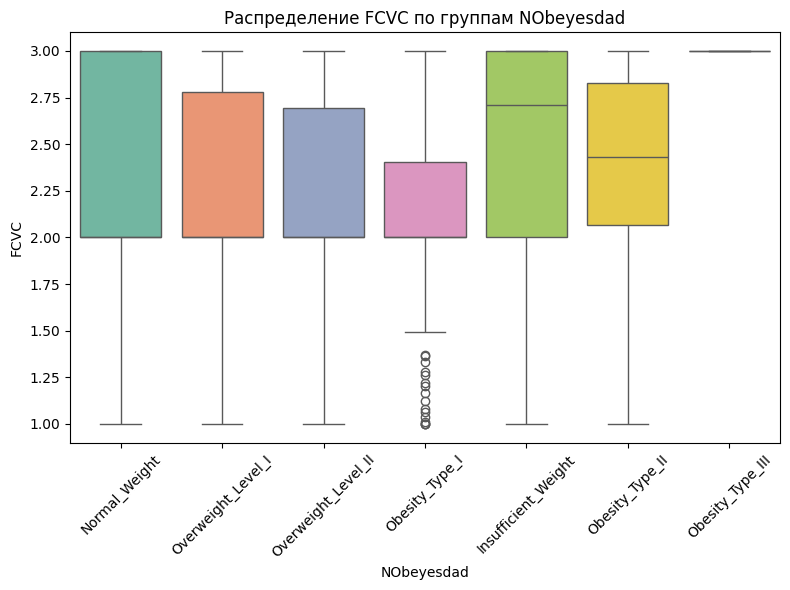

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


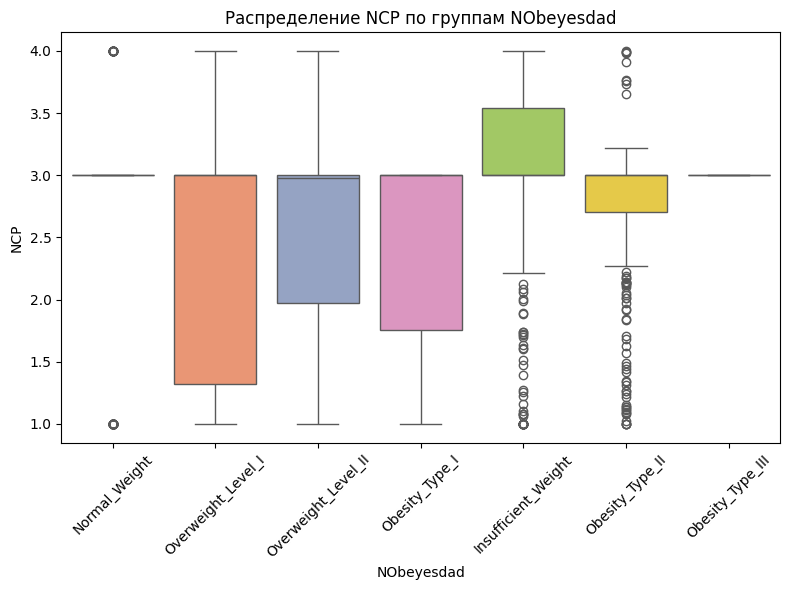

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


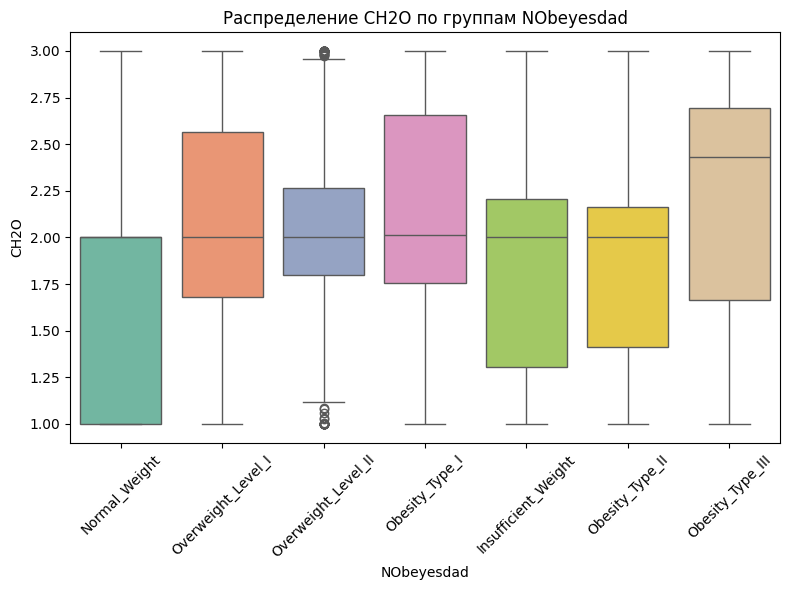

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


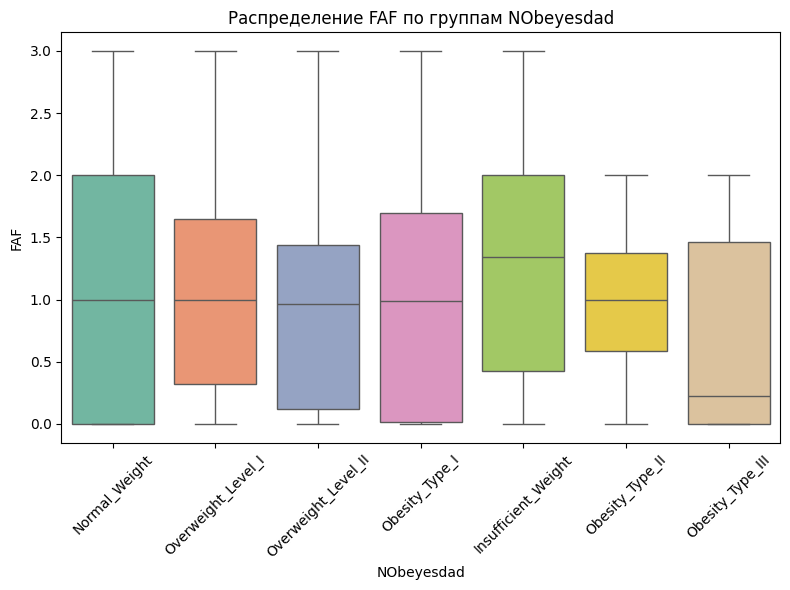

/tmp/ipykernel_1199/904728340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


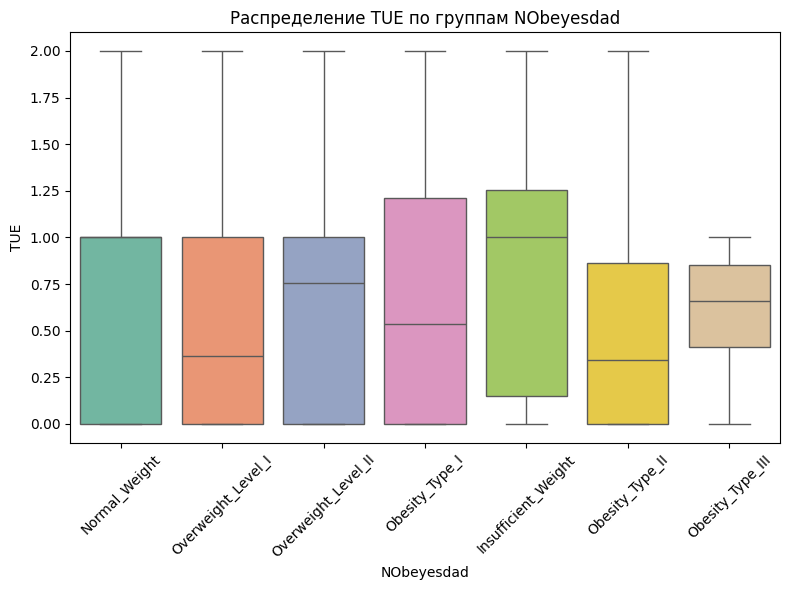

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=target_col, y=col, palette='Set2')
    plt.xticks(rotation=45)
    plt.title(f'Распределение {col} по группам {target_col}')
    plt.tight_layout()
    plt.show()

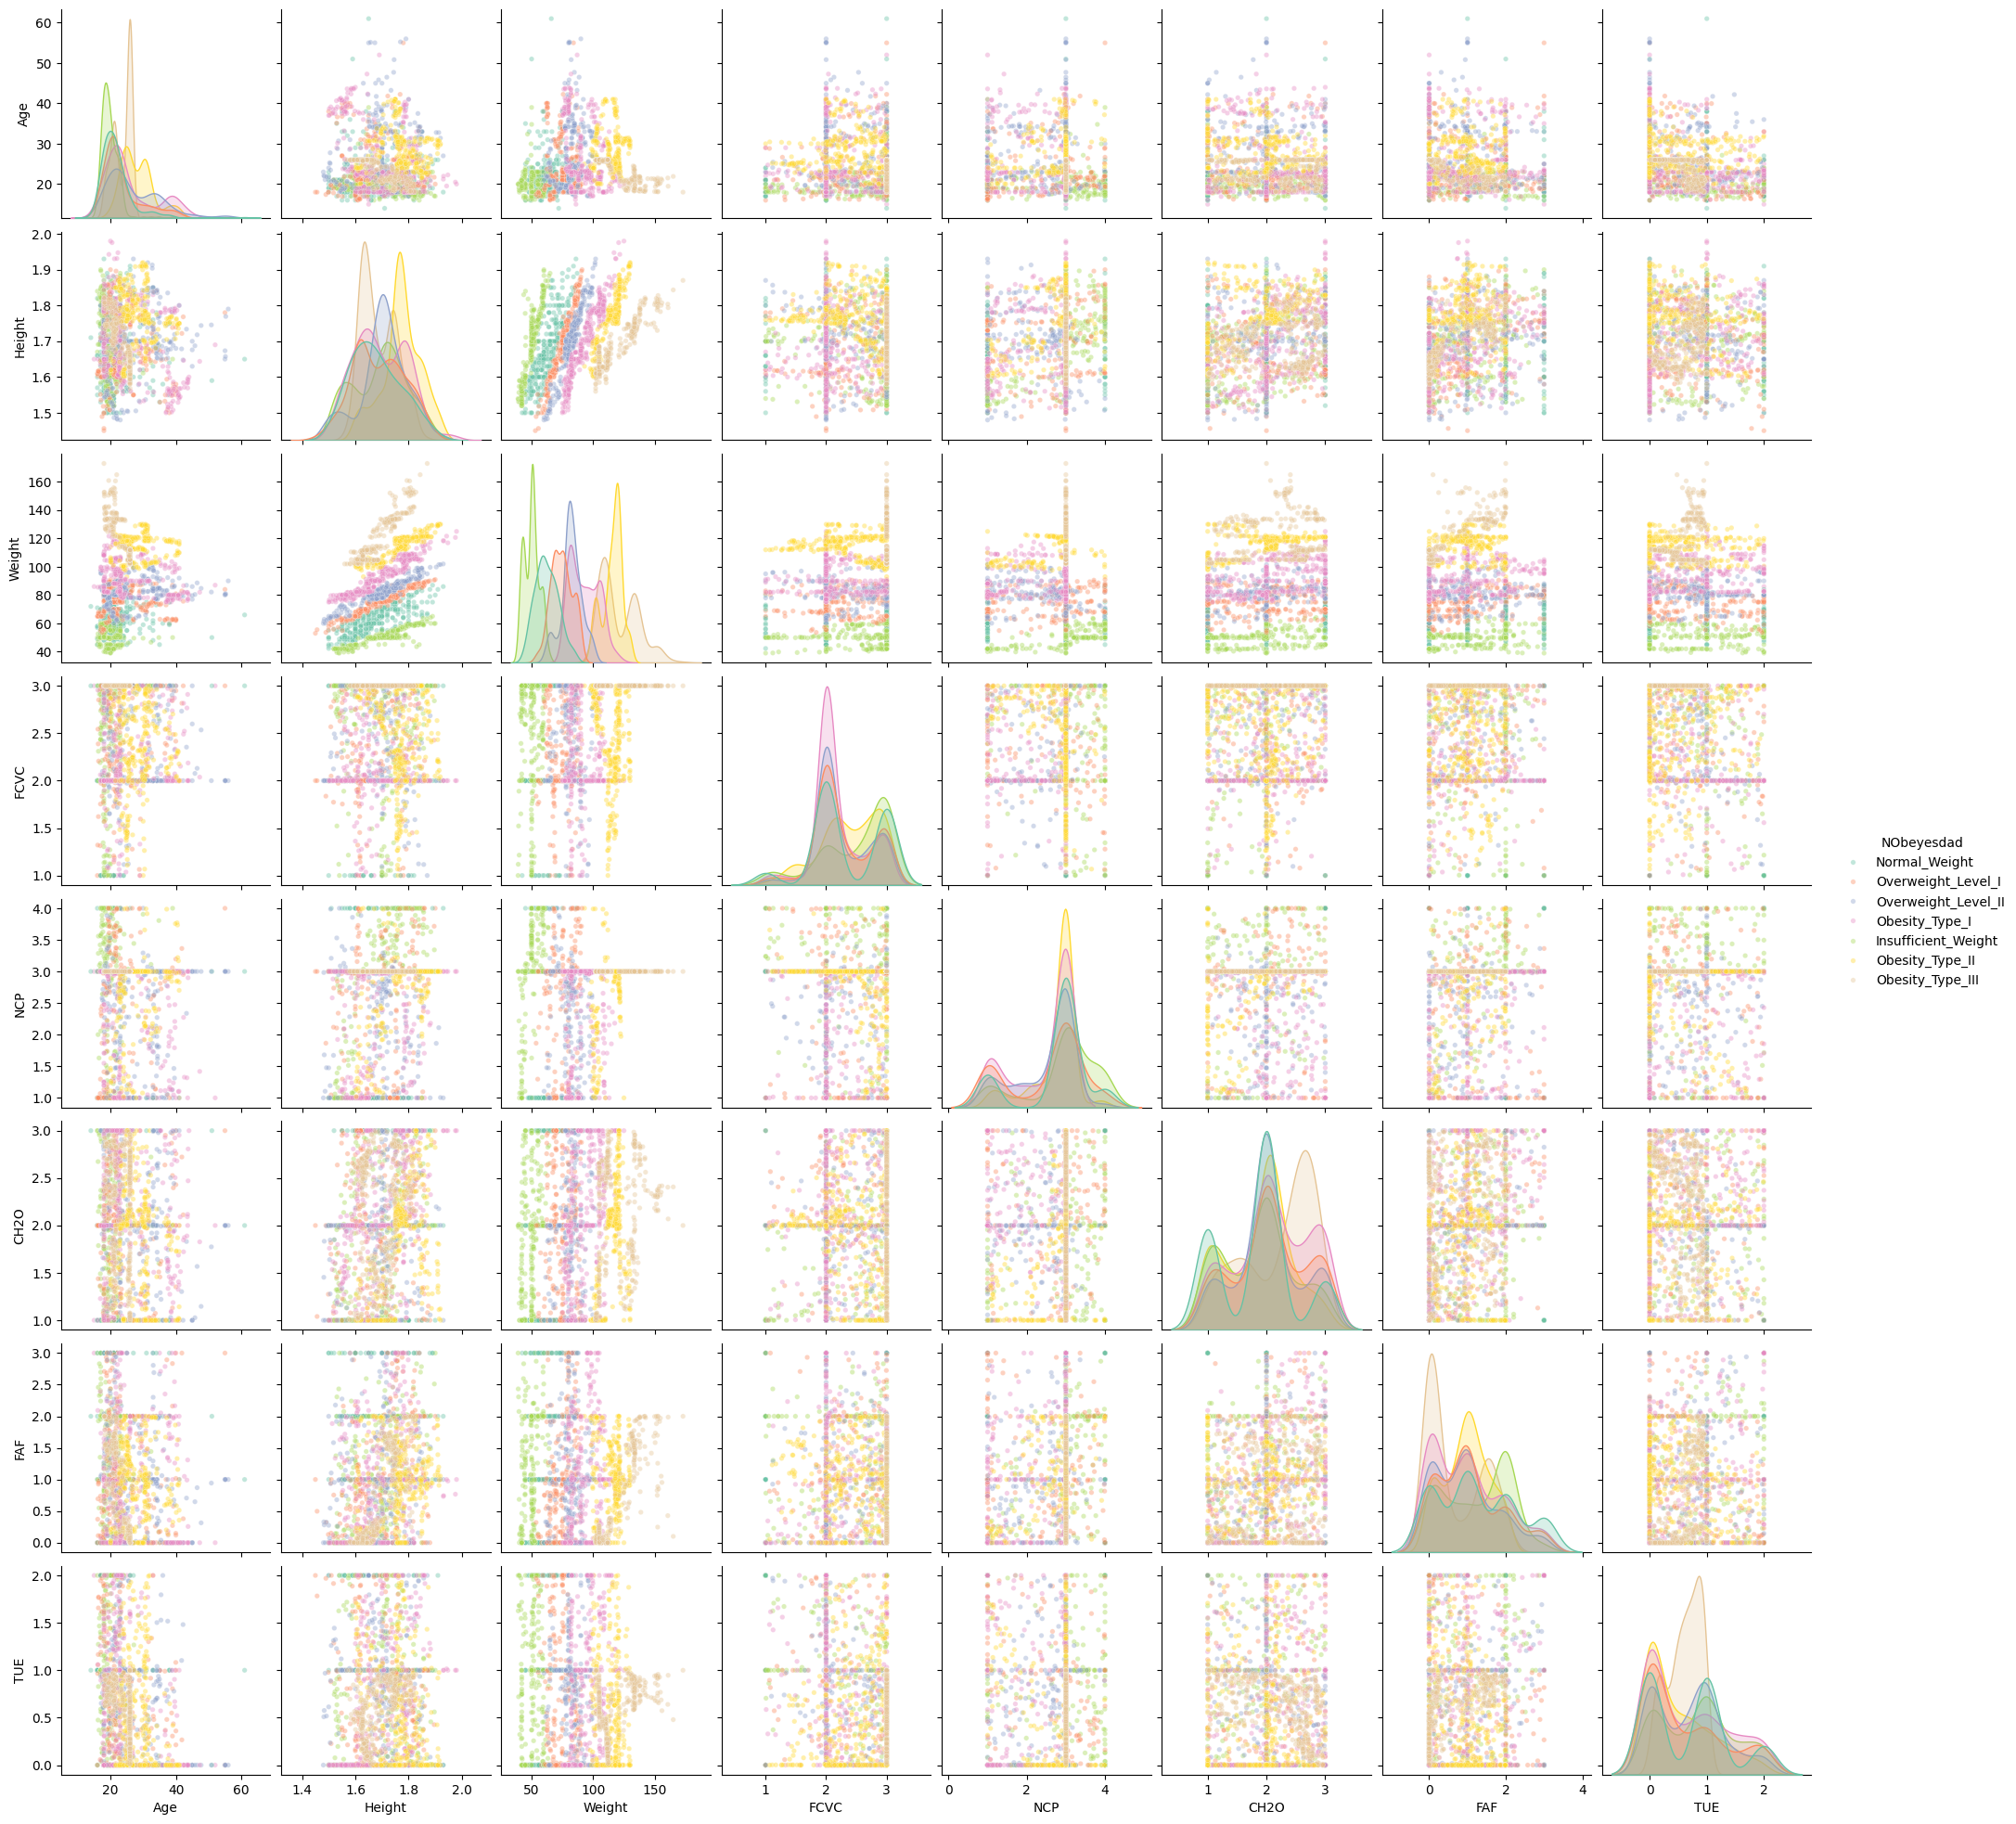

In [12]:
sns.pairplot(df[numeric_cols + [target_col]],
             hue=target_col, palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

onehot, labelencoding

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder,MinMaxScaler

feature_cols = ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP',
       'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE',
       'CAEC', 'MTRANS']
X_all = df[feature_cols].copy()
y_all = df['NObeyesdad'].copy()

categorical_cols = ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
                    'family_history_with_overweight', 'CAEC', 'MTRANS']
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


le = LabelEncoder()
y_all_encoded = le.fit_transform(y_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all_encoded, test_size=0.2, random_state=123
)

X_cat = X_all[categorical_cols]

onht = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_cat = onht.fit_transform(X_train[categorical_cols])
X_test_cat = onht.transform(X_test[categorical_cols])

cat_feature_names = onht.get_feature_names_out(categorical_cols)
X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=cat_feature_names,
    index=X_train.index
)
X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=cat_feature_names,
    index=X_test.index
)

X_train = pd.concat([X_train_cat, X_train[numerical_cols]], axis=1)
X_test = pd.concat([X_test_cat, X_test[numerical_cols]], axis=1)

X_train.head()

,Gender_Male,CALC_Frequently,CALC_Sometimes,CALC_no,FAVC_yes,SCC_yes,SMOKE_yes,family_history_with_overweight_yes,CAEC_Frequently,CAEC_Sometimes,...,MTRANS_Public_Transportation,MTRANS_Walking,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
591,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,19.556729,1.767563,56.307019,2.362918,4.000000,2.358172,2.000000,0.939819
1131,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,24.320154,1.577921,65.293179,2.034140,2.741413,1.996384,1.276552,1.019452
395,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,20.000000,1.540000,39.000000,1.000000,3.000000,2.000000,3.000000,2.000000
1035,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,17.971574,1.720379,85.000000,2.000000,3.000000,2.802498,1.000000,0.417580
148,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,27.000000,1.600000,61.000000,3.000000,3.000000,2.000000,0.000000,0.000000


In [14]:
df.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP',
       'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE',
       'CAEC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

logreg_mn + ovr

In [15]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)


log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)

y_pred_ovr = log_reg_ovr.predict(X_test)
y_pred_mn = log_reg_mn.predict(X_test)

pd.DataFrame({
    'OvR Accuracy': [accuracy_score(y_test, y_pred_ovr)],
    'OvR F1 (macro)': [f1_score(y_test, y_pred_ovr, average='macro')],
    'Softmax Accuracy': [accuracy_score(y_test, y_pred_mn)],
    'Softmax F1 (macro)': [f1_score(y_test, y_pred_mn, average='macro')],
}, index=['LogReg']).round(4)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,OvR Accuracy,OvR F1 (macro),Softmax Accuracy,Softmax F1 (macro)
LogReg,0.7518,0.7331,0.8369,0.8242


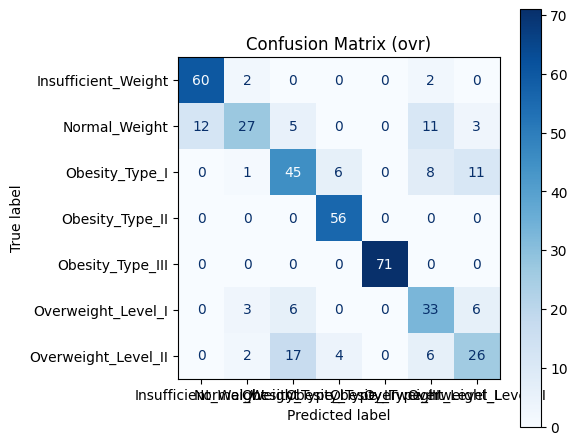

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ovr,
    display_labels=le.classes_,   # ['cat', 'dog', ...]
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (ovr)')
plt.tight_layout()
plt.show()

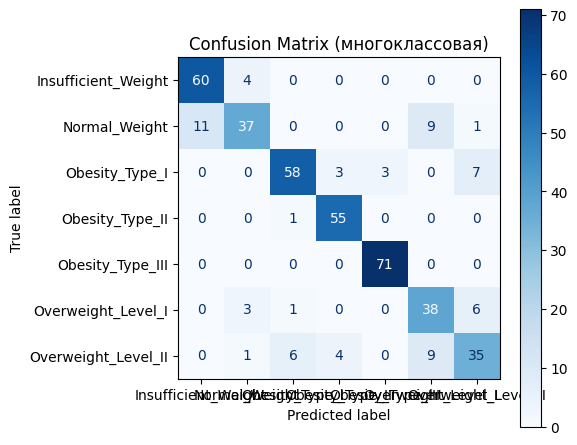

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mn,
    display_labels=le.classes_,
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (многоклассовая)')
plt.tight_layout()
plt.show()

Нормируем данные(standartScaler)

In [18]:
stnd_scal = StandardScaler()
X_train_scal = stnd_scal.fit_transform(X_train[numerical_cols])
X_test_scal = stnd_scal.transform(X_test[numerical_cols])

X_train_scal = pd.DataFrame(
    X_train_scal,
    columns=numerical_cols,
    index=X_train.index
)
X_test_scal = pd.DataFrame(
    X_test_scal,
    columns=numerical_cols,
    index=X_test.index
)

X_train_scal = pd.concat([X_train_cat, X_train_scal], axis=1)
X_test_scal = pd.concat([X_test_cat, X_test_scal], axis=1)

X_train_scal.head()

,Gender_Male,CALC_Frequently,CALC_Sometimes,CALC_no,FAVC_yes,SCC_yes,SMOKE_yes,family_history_with_overweight_yes,CAEC_Frequently,CAEC_Sometimes,...,MTRANS_Public_Transportation,MTRANS_Walking,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
591,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,-0.752243,0.714226,-1.155061,-0.103300,1.696092,0.569805,1.161230,0.435482
1131,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,-0.005287,-1.287913,-0.812299,-0.719873,0.095449,-0.015401,0.313888,0.564398
395,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,-0.682733,-1.688263,-1.815207,-2.659246,0.424314,-0.009552,2.332485,2.151785
1035,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,-1.000812,0.216082,-0.060616,-0.783897,0.424314,1.288520,-0.010025,-0.409958
148,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.414942,-1.054815,-0.976055,1.091451,0.424314,-0.009552,-1.181280,-1.085969


Те же 2 модели, но со standartScaler

In [19]:
log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train_scal, y_train)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scal, y_train)

y_pred_ovr_scal = log_reg_ovr.predict(X_test_scal)
y_pred_mn_scal = log_reg_mn.predict(X_test_scal)

pd.DataFrame({
    'OvR Accuracy': [accuracy_score(y_test, y_pred_ovr_scal)],
    'OvR F1 (macro)': [f1_score(y_test, y_pred_ovr_scal, average='macro')],
    'Softmax Accuracy': [accuracy_score(y_test, y_pred_mn_scal)],
    'Softmax F1 (macro)': [f1_score(y_test, y_pred_mn_scal, average='macro')],
}, index=['LogReg']).round(4)



,OvR Accuracy,OvR F1 (macro),Softmax Accuracy,Softmax F1 (macro)
LogReg,0.792,0.7776,0.9149,0.9082


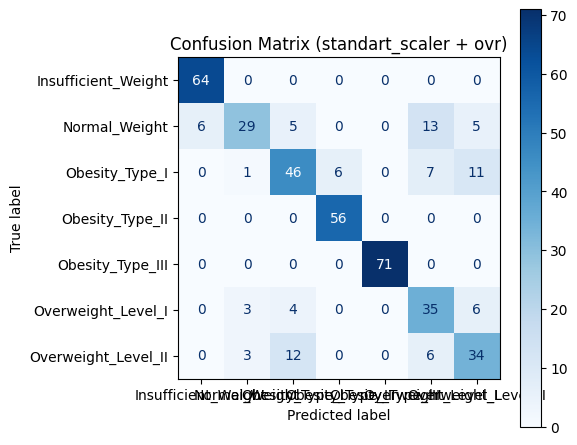

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ovr_scal,
    display_labels=le.classes_,   # ['cat', 'dog', ...]
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (standart_scaler + ovr)')
plt.tight_layout()
plt.show()

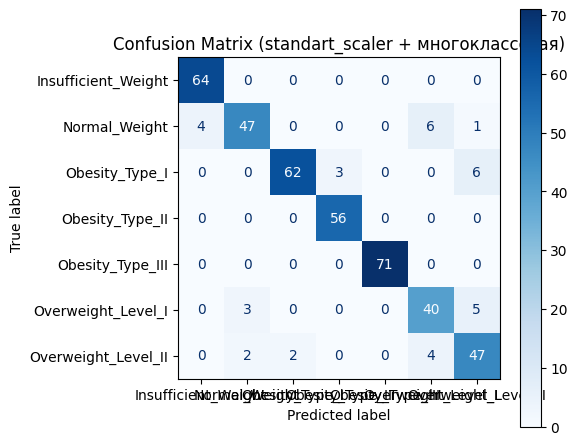

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mn_scal,
    display_labels=le.classes_,   # ['cat', 'dog', ...]
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (standart_scaler + многоклассовая)')
plt.tight_layout()
plt.show()

Попытка minmaxscaler

In [22]:
mnmx_scal = MinMaxScaler()
X_train_mnmx = mnmx_scal.fit_transform(X_train[numerical_cols])
X_test_mnmx = mnmx_scal.transform(X_test[numerical_cols])

X_train_mnmx = pd.DataFrame(
    X_train_mnmx,
    columns=numerical_cols,
    index=X_train.index
)
X_test_mnmx = pd.DataFrame(
    X_test_mnmx,
    columns=numerical_cols,
    index=X_test.index
)

X_train_mnmx = pd.concat([X_train_cat, X_train_mnmx], axis=1)
X_test_mnmx = pd.concat([X_test_cat, X_test_mnmx], axis=1)

X_train_mnmx.head()

,Gender_Male,CALC_Frequently,CALC_Sometimes,CALC_no,FAVC_yes,SCC_yes,SMOKE_yes,family_history_with_overweight_yes,CAEC_Frequently,CAEC_Sometimes,...,MTRANS_Public_Transportation,MTRANS_Walking,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
591,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.118228,0.599175,0.129157,0.681459,1.000000,0.679086,0.666667,0.469909
1131,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.219578,0.241360,0.196218,0.517070,0.580471,0.498192,0.425517,0.509726
395,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.127660,0.169811,0.000000,0.000000,0.666667,0.500000,1.000000,1.000000
1035,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.084502,0.510149,0.343284,0.500000,0.666667,0.901249,0.333333,0.208790
148,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.276596,0.283019,0.164179,1.000000,0.666667,0.500000,0.000000,0.000000


Плохо получилось с minmax

In [23]:
log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train_mnmx, y_train)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_mnmx, y_train)

y_pred_ovr_mnmx = log_reg_ovr.predict(X_test_mnmx)
y_pred_mn_mnmx = log_reg_mn.predict(X_test_mnmx)

pd.DataFrame({
    'OvR Accuracy': [accuracy_score(y_test, y_pred_ovr_mnmx)],
    'OvR F1 (macro)': [f1_score(y_test, y_pred_ovr_mnmx, average='macro')],
    'Softmax Accuracy': [accuracy_score(y_test, y_pred_mn_mnmx)],
    'Softmax F1 (macro)': [f1_score(y_test, y_pred_mn_mnmx, average='macro')],
}, index=['LogReg']).round(4)



,OvR Accuracy,OvR F1 (macro),Softmax Accuracy,Softmax F1 (macro)
LogReg,0.7139,0.6908,0.7447,0.7239


Дерево с standartscaler и всеми признаками

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_cls = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini')
dt_cls.fit(X_train_scal, y_train)
y_pred_dt = dt_cls.predict(X_test_scal)

pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_pred_dt)],
    'F1 (macro)': [f1_score(y_test, y_pred_dt, average='macro')],
}, index=['DecisionTree (depth=5)']).round(4)

,Accuracy,F1 (macro)
DecisionTree (depth=5),0.8416,0.8243


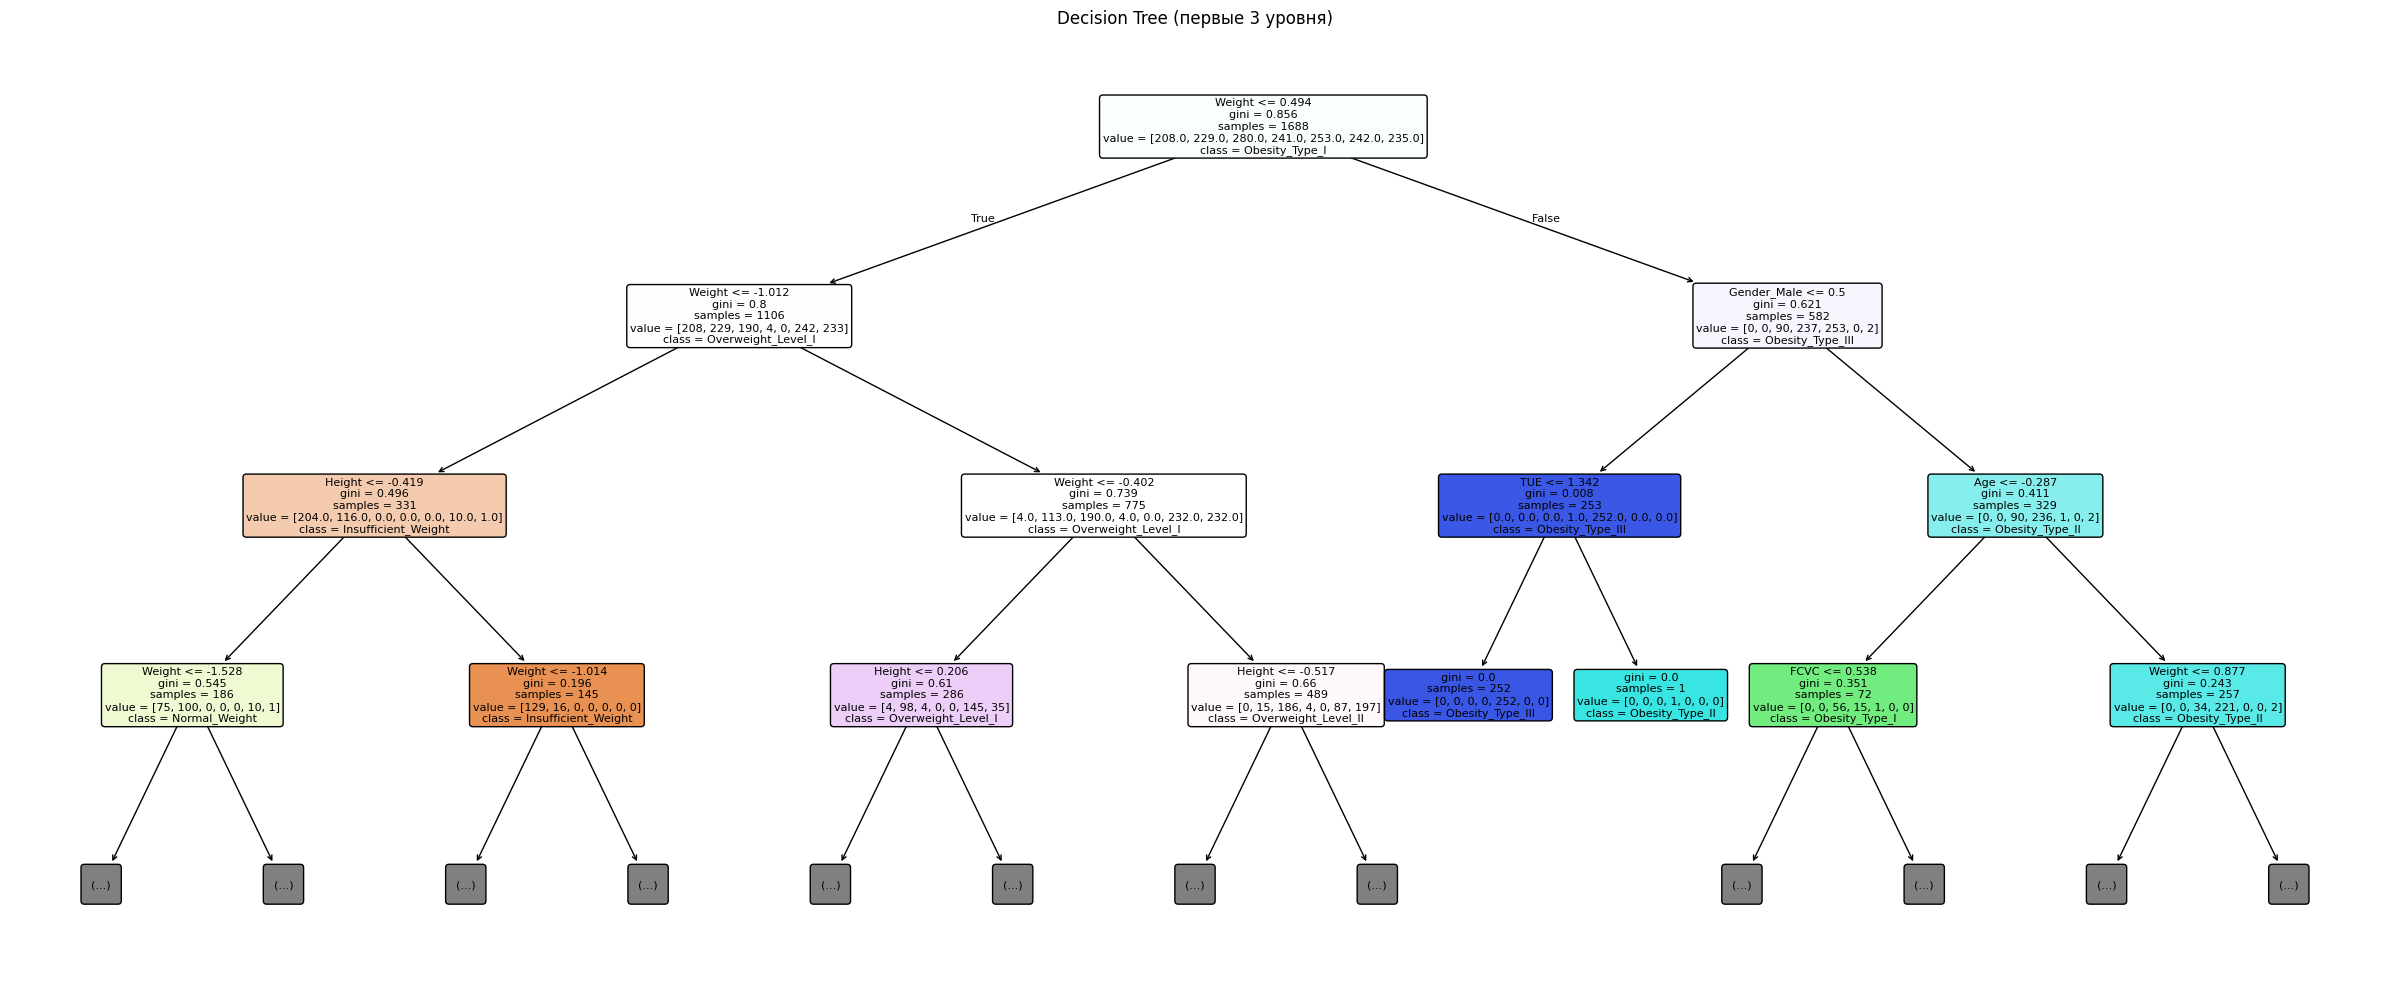

In [25]:
feature_names = X_train_scal.columns.tolist()
class_names = le.classes_.tolist()

plt.figure(figsize=(24, 10))
plot_tree(dt_cls, max_depth=3, feature_names=feature_names,
          class_names=class_names, filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (первые 3 уровня)')
plt.tight_layout()
plt.show()

Исследуем оптимальную глубина на всех признаках с standartscaler. Глубина 10-15 оптимально, потом проверим с gridsearch.

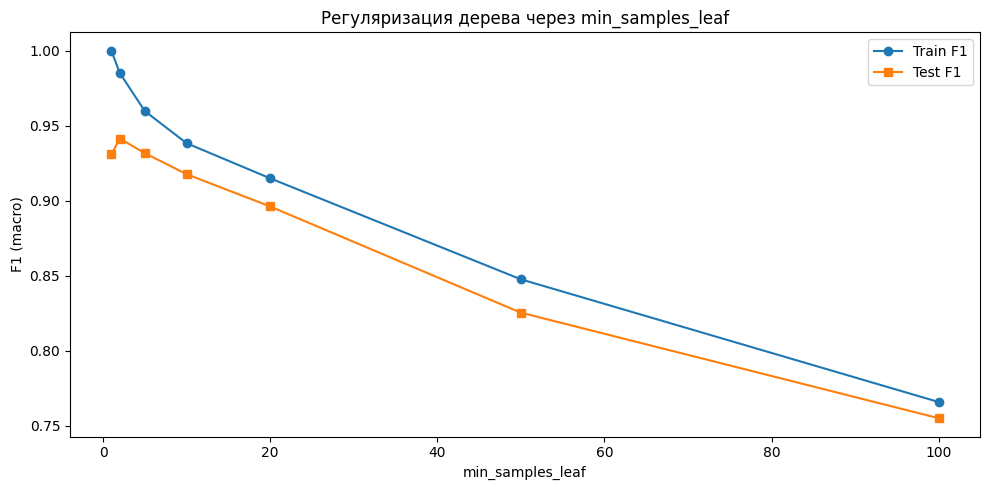

In [26]:
leafs = [1, 2, 5, 10, 20, 50, 100]
train_f1, test_f1 = [], []

for ml in leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=ml, random_state=42).fit(X_train_scal, y_train)
    train_f1.append(f1_score(y_train, dt.predict(X_train_scal), average='macro'))
    test_f1.append(f1_score(y_test, dt.predict(X_test_scal), average='macro'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(leafs, train_f1, 'o-', label='Train F1')
ax.plot(leafs, test_f1, 's-', label='Test F1')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('F1 (macro)')
ax.set_title('Регуляризация дерева через min_samples_leaf')
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
results_crit = []
for crit in ['gini', 'entropy']:
    for d in [1, 2, 3, 5, 10, 15, None]:
        dt = DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=42).fit(X_train_scal, y_train)
        results_crit.append({
            'criterion': crit,
            'max_depth': d,
            'train_acc': accuracy_score(y_train, dt.predict(X_train_scal)),
            'test_acc': accuracy_score(y_test, dt.predict(X_test_scal)),
        })
pd.DataFrame(results_crit).round(4)

,criterion,max_depth,train_acc,test_acc
0,gini,1.0,0.2932,0.2813
1,gini,2.0,0.5474,0.5579
2,gini,3.0,0.6523,0.6548
3,gini,5.0,0.8489,0.8416
4,gini,10.0,0.9988,0.9314
5,gini,15.0,1.0000,0.9338
6,gini,NaN,1.0000,0.9338
7,entropy,1.0,0.2932,0.2813
8,entropy,2.0,0.5492,0.5579
9,entropy,3.0,0.6463,0.6454


Самые важные признаки у дерева

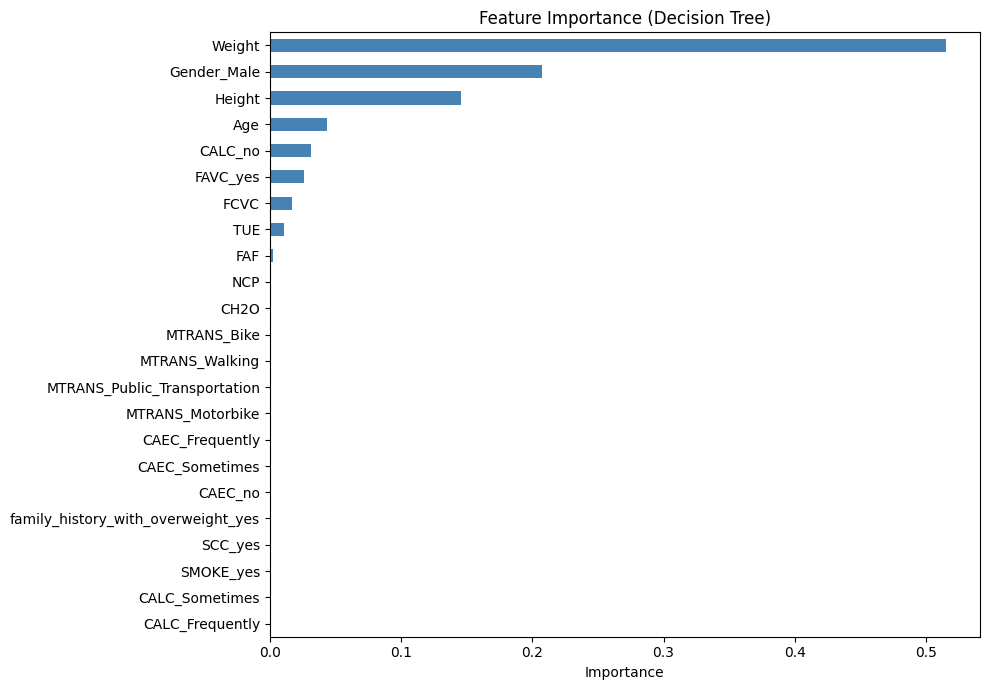

In [28]:
best_dt = dt_cls
importances = pd.Series(best_dt.feature_importances_, index=X_train_scal.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Decision Tree)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Оставляем только 4 самых важных признака

In [29]:
short_features = ['Weight', 'Gender_Male', 'Height', 'Age']
X_train_short = X_train_scal[short_features]
X_test_short = X_test_scal[short_features]



In [30]:
log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train_short, y_train)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_short, y_train)

y_pred_ovr_short = log_reg_ovr.predict(X_test_short)
y_pred_mn_short = log_reg_mn.predict(X_test_short)

pd.DataFrame({
    'OvR Accuracy': [accuracy_score(y_test, y_pred_ovr)],
    'OvR F1 (macro)': [f1_score(y_test, y_pred_ovr, average='macro')],
    'Softmax Accuracy': [accuracy_score(y_test, y_pred_mn)],
    'Softmax F1 (macro)': [f1_score(y_test, y_pred_mn, average='macro')],
}, index=['LogReg']).round(4)

,OvR Accuracy,OvR F1 (macro),Softmax Accuracy,Softmax F1 (macro)
LogReg,0.7518,0.7331,0.8369,0.8242


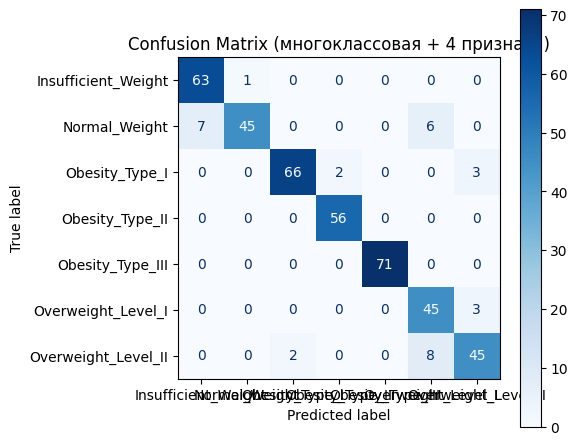

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mn_short,
    display_labels=le.classes_,
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (многоклассовая + 4 признака)')
plt.tight_layout()
plt.show()

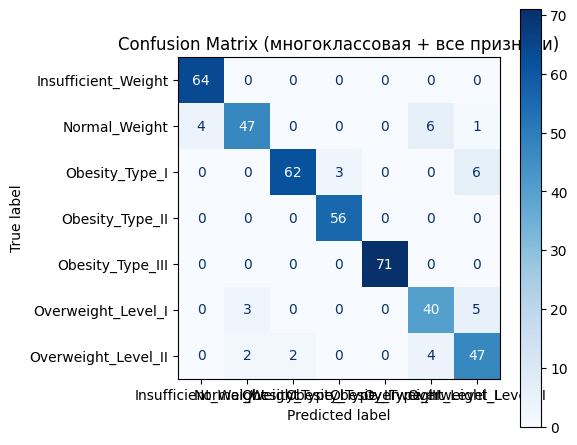

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mn_scal,
    display_labels=le.classes_,
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (многоклассовая + все признаки)')
plt.tight_layout()
plt.show()

Делаем только 2 признака bmi и age

In [33]:
df = X_all.copy()


df['BMI'] = df['Weight'] / (df['Height'] ** 2)

X_bmi = df[['BMI', 'Age']]
X_train_bmi, X_test_bmi, y_train, y_test = train_test_split(
    X_bmi, y_all_encoded, test_size=0.2, random_state=123
)

log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train_bmi, y_train)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_bmi, y_train)

y_pred_ovr = log_reg_ovr.predict(X_test_bmi)
y_pred_mn = log_reg_mn.predict(X_test_bmi)

pd.DataFrame({
    'OvR Accuracy': [accuracy_score(y_test, y_pred_ovr)],
    'OvR F1 (macro)': [f1_score(y_test, y_pred_ovr, average='macro')],
    'Softmax Accuracy': [accuracy_score(y_test, y_pred_mn)],
    'Softmax F1 (macro)': [f1_score(y_test, y_pred_mn, average='macro')],
}, index=['LogReg']).round(4)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,OvR Accuracy,OvR F1 (macro),Softmax Accuracy,Softmax F1 (macro)
LogReg,0.7754,0.7622,0.9504,0.9507


In [43]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_cls = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini')
dt_cls.fit(X_train_bmi, y_train)
y_pred_dt = dt_cls.predict(X_test_bmi)

pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_pred_dt)],
    'F1 (macro)': [f1_score(y_test, y_pred_dt, average='macro')],
}, index=['DecisionTree (depth=5)']).round(4)



,Accuracy,F1 (macro)
DecisionTree (depth=5),0.9527,0.9541


дерево с cv и gridsearch с двумя признаками(bmi, age)

In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'max_depth':        [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    'min_samples_split':[2, 5, 10, 20],
    'criterion':        ['gini', 'entropy'],
}


dt = DecisionTreeClassifier(random_state=42)

gs = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    verbose=1,
)

gs.fit(X_train_bmi, y_train)


print('Best params :', gs.best_params_)
print('Best CV F1 macro:', round(gs.best_score_, 4))


best_dt = gs.best_estimator_
y_pred_best = best_dt.predict(X_test_bmi)

pd.DataFrame({
    'Accuracy':   [accuracy_score(y_test, y_pred_best)],
    'F1 (macro)': [f1_score(y_test, y_pred_best, average='macro')],
}, index=['DecisionTree (GridSearch)']).round(4)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV F1 macro: 0.9594


,Accuracy,F1 (macro)
DecisionTree (GridSearch),0.9456,0.9437


дерево с cv и gridsearch с двумя признаками(bmi, age) + standartscaler. standart scaler не дал прироста(вероятно bmi и age примерно числа одного порядка(оба от 0 до 100)).

In [46]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42)),
])

param_grid = {
    'clf__max_depth':         [3, 5, 7, 10, 15, None],
    'clf__min_samples_leaf':  [1, 2, 5, 10, 20, 50],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__criterion':         ['gini', 'entropy'],
}


gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    verbose=1,
)

gs.fit(X_train_bmi, y_train)

print('Best params :', gs.best_params_)
print('Best CV F1 macro:', round(gs.best_score_, 4))

# --- Оценка на отложенном test
best_pipe = gs.best_estimator_
y_pred_best = best_pipe.predict(X_test_bmi)

pd.DataFrame({
    'Accuracy':   [accuracy_score(y_test, y_pred_best)],
    'F1 (macro)': [f1_score(y_test, y_pred_best, average='macro')],
}, index=['DecisionTree + Scaler (GridSearch)']).round(4)



Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params : {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}
Best CV F1 macro: 0.9594


,Accuracy,F1 (macro)
DecisionTree + Scaler (GridSearch),0.9456,0.9437


bmi + age с logreg, сравниваем с standartScaler и без.

In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


log_reg_mn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])

res_scaled = cross_validate(
    log_reg_mn_scaled, X_train_bmi, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1,
)

log_reg_mn = LogisticRegression(max_iter=1000, random_state=42)
res_unscaled = cross_validate(
    log_reg_mn, X_train_bmi, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1,
)

summary = pd.DataFrame({
    'CV Accuracy':    [res_unscaled['test_accuracy'].mean(),
                       res_scaled['test_accuracy'].mean()],
    'CV F1 macro':    [res_unscaled['test_f1_macro'].mean(),
                       res_scaled['test_f1_macro'].mean()],
    'Train F1 macro': [res_unscaled['train_f1_macro'].mean(),
                       res_scaled['train_f1_macro'].mean()],
}, index=['LogReg (softmax, no scaler)', 'LogReg (softmax, + StandardScaler)']).round(4)

print(summary)

                                    CV Accuracy  CV F1 macro  Train F1 macro
LogReg (softmax, no scaler)              0.9354       0.9359          0.9388
LogReg (softmax, + StandardScaler)       0.8714       0.8696          0.8779


logreg с cv и gridsearch с двумя признаками(bmi, age)

Итоговая confusion matrix(logreg+bmi,age)

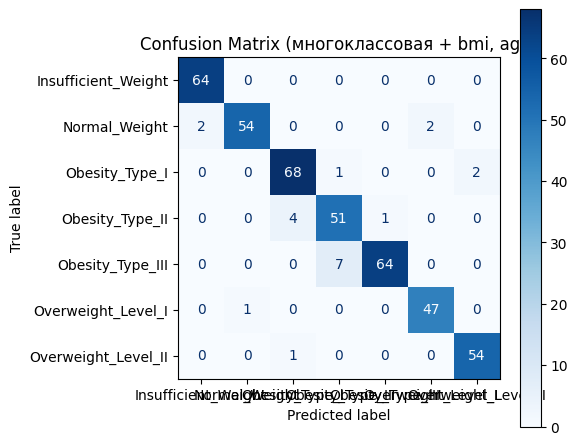

In [39]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mn,
    display_labels=le.classes_,
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix (многоклассовая + bmi, age)')
plt.tight_layout()
plt.show()

Итоговое дерево с лучшими параметрами и bmi+age

                      Accuracy  F1 (macro)
DecisionTree — train    0.9745      0.9747
DecisionTree — test     0.9456      0.9437


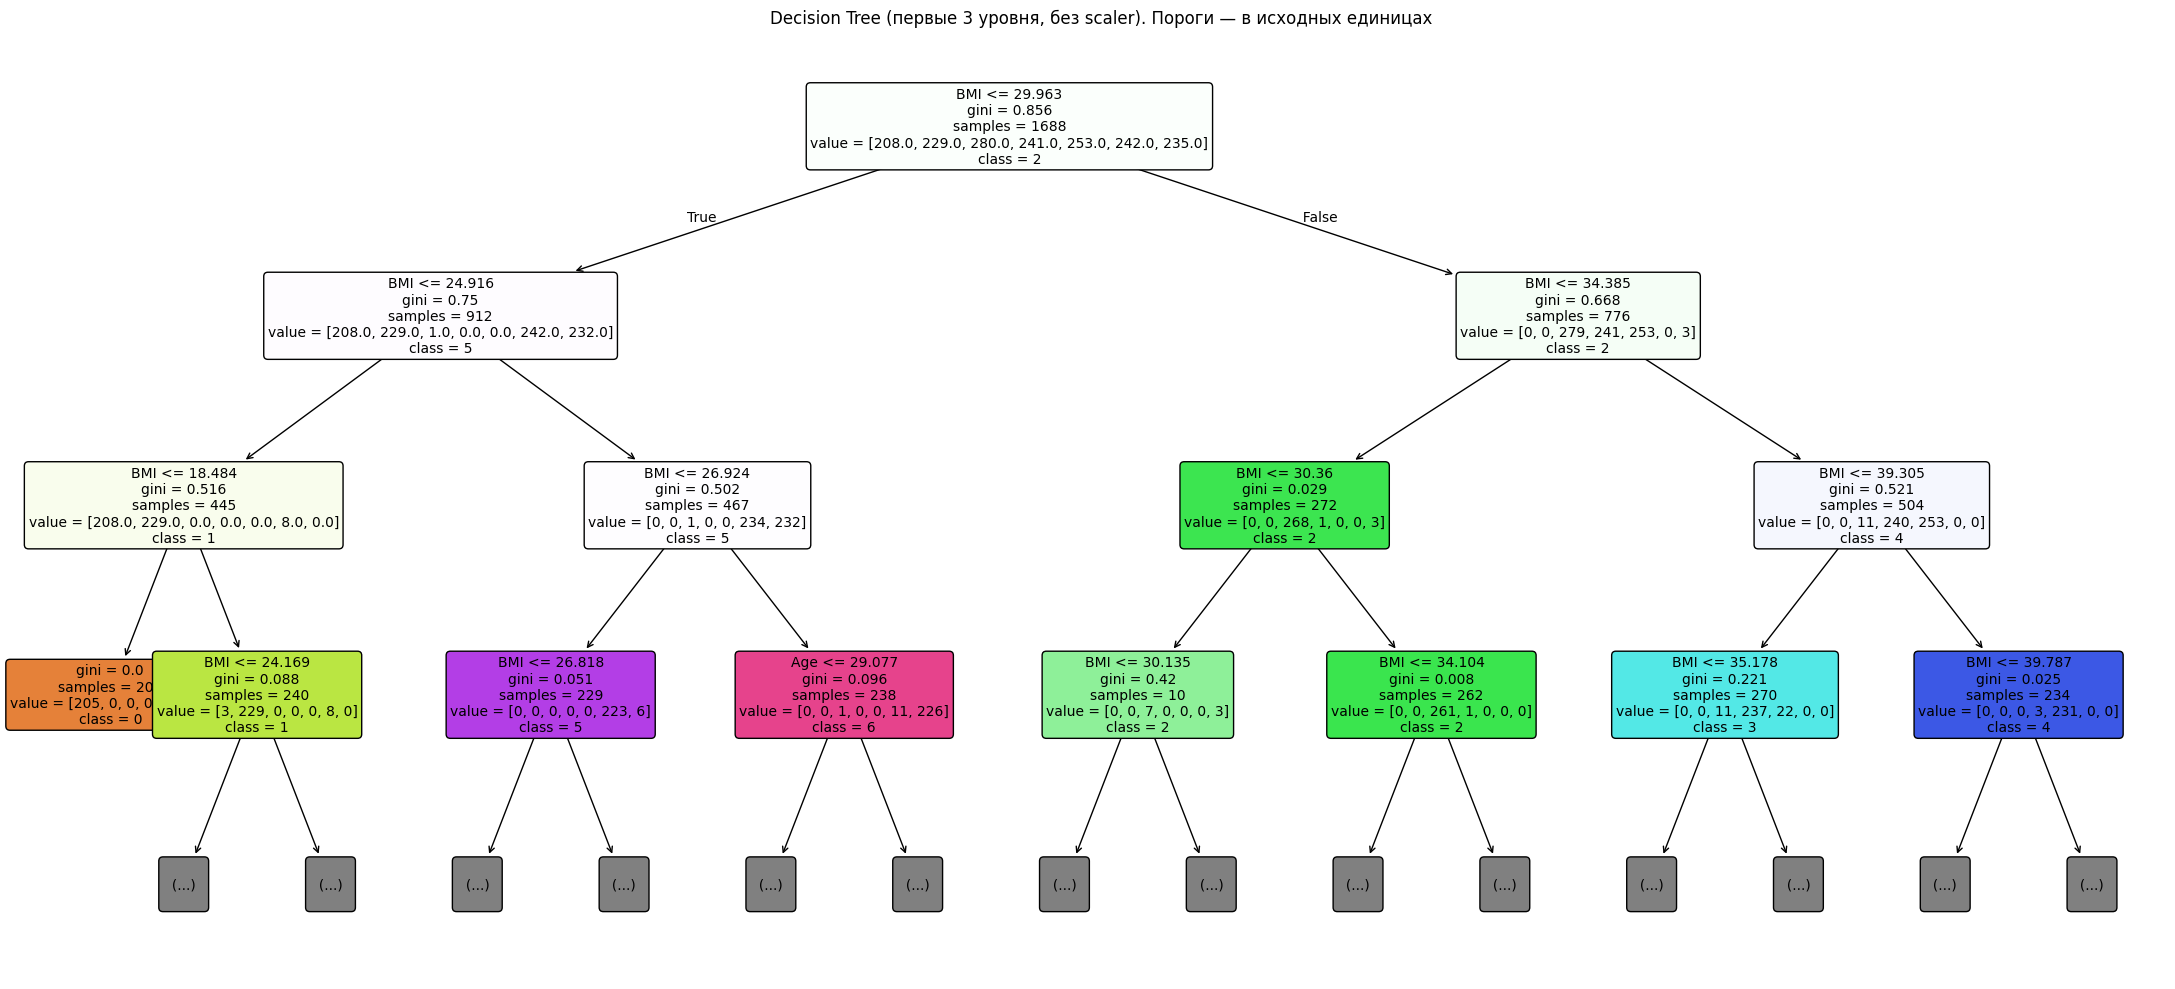

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

# --- Лучшие параметры, найденные GridSearchCV (без префикса clf__)
best_params = {
    'max_depth':         None,   # подставь своё значение из gs.best_params_
    'min_samples_leaf':  5,
    'min_samples_split': 10,
    'criterion':         'gini',
    'random_state':      42,
}

# --- Обучение дерева без scaler, на исходных признаках
clf = DecisionTreeClassifier(**best_params)
clf.fit(X_train_bmi, y_train)

# --- Метрики на train и test
y_pred_train = clf.predict(X_train_bmi)
y_pred_test  = clf.predict(X_test_bmi)

metrics = pd.DataFrame({
    'Accuracy':   [accuracy_score(y_train, y_pred_train),
                   accuracy_score(y_test,  y_pred_test)],
    'F1 (macro)': [f1_score(y_train, y_pred_train, average='macro'),
                   f1_score(y_test,  y_pred_test,  average='macro')],
}, index=['DecisionTree — train', 'DecisionTree — test']).round(4)

print(metrics)

# --- Отрисовка дерева
feature_names = X_train_bmi.columns.tolist()
class_names   = [str(c) for c in clf.classes_]

plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    max_depth=3,              # глубина отрисовки (не модели!)
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True,
    proportion=False,
)
plt.title('Decision Tree (первые 3 уровня, без scaler). Пороги — в исходных единицах')
plt.tight_layout()
plt.show()